# Ensemble methods for individual customer OrderQuantity value prediction

In [1]:
%pip install nbformat pandas numpy matplotlib seaborn scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
import sys
sys.path.append('../../src')

In [4]:
from data_config import ProductHandler as ph

In [5]:
ph.custom_prod_set()

All custom codes for existing products: 
{'01Y', 'DEV', 'DO-', '213', 'FRE', '-03', '03Y', '2-0', '39Y', '93Z', '70Z', '165', '05Y', '111', '299', '14-', '081', 'BAN', '470', '249', '016', '385', '028', '92Y', '161', '17V', '51Z', '228', 'UI-', '96Y', 'AT-', 'NC-', '88Y', '118', '130', '45Z', 'QUI', '05-', '048', '051', '082', '70Y', 'NAF', '025', '275', '076', '78Z', '190', '06X', '156', '46W', '129', '90Z', '09Z', '068', 'ITW', '099', '93Y', '61Y', '98Z', '186', '08Z', '0-0', 'O-0', 'L-0', '094', '05X', '103', '61Z', '046', '207', 'CPF', '96Z', '304', 'GOL', 'HF-', '18Z', '043', '10Z', '22Z', '44-', '138', 'AHF', '54Z', 'H-0', '03Z', '216', '014', '007', 'B-0', '058', '47Y', '00Y', '27Z', '57Z', '-00', '225', '153', 'HSP', 'HIG', '054', '04Y', '34X', '313', '05Z', '89Z', 'UMA', '121', '44Y', '01Z', 'BRI', '126', '347', '48W', '368', '03-', '443', '012', 'SP-', '049', '352', '001', '149', '152', '28Z', '303', 'AH-', '15Y', '163', '340', '09X', '371', '28W', 'TW-', '77Z', 'RE-', '48Y',

In [6]:
# define the features and target variable from 'product_sales'
# CHANGE THE CUSTOMER CODE HERE >>>>>>>>>>
custom_code_df = pd.DataFrame(ph.get_custom_code_data('FRE'))

# customer code for later referencing
custom_ref = custom_code_df.loc[0, 'ProductNumber'][:3].lower().upper()
print(custom_ref)

custom_code_df.head()

FRE


,ProductNumber,order_year,order_month,order_week,order_weekday,is_weekend,OrderDate,Customer_Num,OrderQuantity,prev_month_sales,...,moving_avg_3m,moving_avg_6m,moving_avg_12m,moving_avg_18m,sales_2022,sales_2023,sales_2024,growth_2023,growth_2024,PhysicalInv
0,FRE-005-0245Z,2024,11,46,1,0,2024-10-23,48.0,43221,39749.766102,...,31225.097154,57749.678519,67920.312832,74353.139906,130,73,52387,-100.0,-100.0,331
1,FRE-005-0216Y,2024,8,45,6,1,2024-10-04,233.0,20108,17842.272528,...,32403.578734,23031.284126,20237.718027,50989.678767,0,207,13465,-100.0,-100.0,22976
2,FRE-005-0035Y,2022,3,10,2,0,2022-02-09,12.0,216249,337196.618276,...,142902.080720,129059.927220,149550.605957,138865.846818,213197,109,0,-100.0,-100.0,0
3,FRE-005-0239Z,2023,12,32,3,0,2022-09-28,122.0,35986,111010.072759,...,17959.763640,46443.762016,14165.396234,10625.592496,0,21374,82,-100.0,-100.0,371
4,FRE-005-0051Z,2021,12,51,3,0,2022-03-03,15.0,76078,138468.493449,...,188699.564067,153143.726641,111815.316582,241464.249425,0,0,324,-100.0,-100.0,524


In [7]:
from scipy import stats

# Define a function to compute z-scores within each product group
def compute_zscore(group, threshold=3):
    # Only compute z-score if there are at least 2 data points in the group
    if len(group) >= 2:
        group['z_score'] = np.abs(stats.zscore(group['OrderQuantity']))
    else:
        group['z_score'] = 0  # or np.nan if preferred
    return group

# Group by "ProductNumber" and compute z-scores for "OrderQuantity" within each group
df_grouped = custom_code_df.groupby('ProductNumber').apply(compute_zscore)

# Define your threshold for what constitutes an "unusually high" order
z_threshold = 3

# Filter for outliers (orders with a z_score greater than the threshold)
df_outliers = df_grouped[df_grouped['z_score'] > z_threshold]

# Display the results
print("Unusually high order quantities (per ProductNumber):")
print(df_outliers[['ProductNumber', 'OrderQuantity', 'z_score']])

print(f'Dropping: \n{df_outliers.count()}')
# Keep only rows where the z-score is within the acceptable range
df_cleaned = df_grouped[df_grouped['z_score'] <= z_threshold].drop(columns=['z_score'])

# Reset index for clarity
df_cleaned.reset_index(drop=True, inplace=True)

custom_code_df = df_cleaned

Unusually high order quantities (per ProductNumber):
                    ProductNumber  OrderQuantity   z_score
ProductNumber                                             
FRE-005-0013Z 5739  FRE-005-0013Z        1215408  5.983938
              5801  FRE-005-0013Z        1231338  6.068313
              8861  FRE-005-0013Z         664616  3.066593
FRE-005-0015Y 1555  FRE-005-0015Y        1309984  5.012933
              5070  FRE-005-0015Y        1104780  4.141313
...                           ...            ...       ...
FRE-005-0351Z 3435  FRE-005-0351Z         920012  3.805258
              7488  FRE-005-0351Z         985558  4.126683
              9328  FRE-005-0351Z        1101958  4.697485
FRE-005-0352Z 1340  FRE-005-0352Z         939979  4.851636
              4095  FRE-005-0352Z        1088323  5.703625

[395 rows x 3 columns]
Dropping: 
ProductNumber         395
order_year            395
order_month           395
order_week            395
order_weekday         395
is_weekend     

C:\Users\44777\AppData\Local\Temp\ipykernel_17548\4254259826.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_grouped = custom_code_df.groupby('ProductNumber').apply(compute_zscore)


In [8]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [9]:
features = ['ProductNumber', 'order_month', 'order_week', 'order_weekday',
            'prev_month_sales', 'prev_week_sales', 'prev_2_month_sales', 'prev_3_month_sales',
            'moving_avg_3m', 'moving_avg_6m', 'moving_avg_12m', 'moving_avg_18m',
            'var_3m', 'var_6m', 'var_12m', 'var_18m',
            'log_var_3m', 'log_var_6m', 'log_var_12m', 'log_var_18m',
            'yoy_growth', 'sales_2023', 'sales_2024']
target = 'OrderQuantity'

# Define categorical and numeric features
categorical_features = ['ProductNumber']
numeric_features = [col for col in features if col not in categorical_features]

# Preprocessing pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numeric_transformer, numeric_features)
    ]
)

In [10]:
df = custom_code_df

X = df[features]
y = df[target]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit and transform the training data (fit and transform used so the preprocessor learns the features)
X_train_preprocessed = preprocessor.fit_transform(X_train)

# Transform the validation data
X_val_preprocessed = preprocessor.transform(X_val)

# Extract feature names from the fitted pipeline
encoded_cat_features = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features)

# Combine categorical and numeric feature names
all_feature_names = list(encoded_cat_features) + numeric_features

# Convert preprocessed data back to DataFrame with correct feature names and index
X_train_preprocessed_df = pd.DataFrame(X_train_preprocessed, columns=all_feature_names, index=X_train.index)
X_val_preprocessed_df = pd.DataFrame(X_val_preprocessed, columns=all_feature_names, index=X_val.index)

In [11]:
customer_total_df = custom_code_df

total_X = customer_total_df[features]
total_y = customer_total_df[target]

total_X_train, total_X_val, total_y_train, total_y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit and transform the training data (fit and transform used so the preprocessor learns the features)
total_X_train_preprocessed = preprocessor.fit_transform(total_X_train)

# Transform the validation data
total_X_val_preprocessed = preprocessor.transform(total_X_val)

# Extract feature names from the fitted pipeline
encoded_cat_features = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features)

# Combine categorical and numeric feature names
all_feature_names = list(encoded_cat_features) + numeric_features

# Convert preprocessed data back to DataFrame with correct feature names and index
total_X_train_preprocessed_df = pd.DataFrame(total_X_train_preprocessed, columns=all_feature_names, index=total_X_train.index)
total_X_val_preprocessed_df = pd.DataFrame(total_X_val_preprocessed, columns=all_feature_names, index=total_X_val.index)

In [12]:
from model_utils import *
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Stacking ensemble
from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor

d:\SCM---ML-Visualisation\tf_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
rf_tuned = RandomForestRegressor( # Tuned model hyperparams from rf ipynb
    criterion='squared_error',
    max_depth=None, 
    min_samples_leaf=2, 
    min_samples_split=2, 
    n_estimators=200, 
    random_state=42
)

mlp_tuned = MLPRegressor( # Tuned model hyperparams from nn ipynb
    activation='relu', 
    alpha=0.001, 
    early_stopping=True, 
    hidden_layer_sizes=64, 
    learning_rate='adaptive',
    learning_rate_init=0.01, 
    max_iter=2000,
    random_state=42, 
    solver='adam'
)

xbg_tuned = XGBRegressor( # Tuned model hyperparams from xgb ipynb
    colsample_bytree=1.0, 
    learning_rate=0.2, 
    max_depth=3, 
    n_estimators=500, 
    random_state=42, 
    reg_alpha=0.1, 
    reg_lambda=1,
    subsample=1.0
)

# Stacking ensemble with RF MLP and MLP

# Change 'alpha' value for different weighting
meta_model = Ridge(alpha=1.0) # Learns how to combine model predictions for best result (prevent overfitting)

stacked_ensemble_tuned = StackingRegressor(
    estimators=[
        ('rf_tuned', rf_tuned),
        ('mlp_tuned', mlp_tuned),
        ('xgb_tuned', xbg_tuned)
    ],
    final_estimator=meta_model
)

In [14]:
# Fit and evaluate the model on both train and validation sets
rf_tuned.fit(X_train_preprocessed, y_train)

# Get RF predictions (validation data)
y_pred_rf = rf_tuned.predict(X_val_preprocessed)

In [15]:
# Fit and evaluate the model on both train and validation sets
mlp_tuned.fit(X_train_preprocessed, y_train)

# Get MLP predictions (validation data)
y_pred_mlp = mlp_tuned.predict(X_val_preprocessed)

In [16]:
# Fit and evaluate the model on both train and validation sets
xbg_tuned.fit(X_train_preprocessed, y_train)

# Get XGB predictions (validation data)
y_pred_xgb = xbg_tuned.predict(X_val_preprocessed)

In [17]:
# Stacking ensemble
stacked_ensemble_tuned.fit(X_train_preprocessed, y_train)

# Get Stacked Ensemble predictions (validation data)
val_pred_stacked = stacked_ensemble_tuned.predict(X_val_preprocessed)
train_pred_stacked = stacked_ensemble_tuned.predict(X_train_preprocessed)


In [18]:
y_pred_ensemble = (y_pred_rf + y_pred_mlp + y_pred_xgb) / 3

mae = mean_absolute_error(y_val, y_pred_ensemble)
mse = mean_squared_error(y_val, y_pred_ensemble)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred_ensemble)

print('------ AVERAGING ENSEMBLE ------')
print(f"MAE: {mae:.2f} \nMSE: {mse:.2f} \nRMSE: {rmse:.2f} \nR²: {r2:.2f}")

------ AVERAGING ENSEMBLE ------
MAE: 42822.32 
MSE: 5404441497.51 
RMSE: 73514.91 
R²: 0.66


In [19]:
weights = [0.3, 0.2, 0.5]  # Weights to set for bias to certain model predictions

# Weighted average of predictions
weighted_preds = (weights[0] * y_pred_rf + weights[1] * y_pred_mlp + weights[2] * y_pred_xgb)

mae = mean_absolute_error(y_val, weighted_preds)
mse = mean_squared_error(y_val, weighted_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, weighted_preds)

print('------ WEIGHTED ENSEMBLE ------')
print(f"MAE: {mae:.2f} \nMSE: {mse:.2f} \nRMSE: {rmse:.2f}\nR²: {r2:.2f}")
print('------------')


------ WEIGHTED ENSEMBLE ------
MAE: 42920.80 
MSE: 5481550473.67 
RMSE: 74037.49
R²: 0.66
------------


In [20]:
train_mae = mean_absolute_error(y_train, train_pred_stacked)
train_mse = mean_squared_error(y_train, train_pred_stacked)
train_rmse = np.sqrt(mse)
train_r2 = r2_score(y_train, train_pred_stacked)

val_mae = mean_absolute_error(y_val, val_pred_stacked)
val_mse = mean_squared_error(y_val, val_pred_stacked)
val_rmse = np.sqrt(mse)
val_r2 = r2_score(y_val, val_pred_stacked)

# Output Stacked evaluation metrics on validation set
print('------ STACKED ENSEMBLE ------')
print(f"-- Training Performance -- \nMAE: {train_mae:.4f} \nMSE: {train_mse:.4f} \nRMSE: {train_rmse:.4f} \nR²: {train_r2:.4f}\n\n")
print(f"-- Testing Performance -- \nMAE: {val_mae:.4f} \nMSE: {val_mse:.4f} \nRMSE: {val_rmse:.4f} \nR²: {val_r2:.4f}")

------ STACKED ENSEMBLE ------
-- Training Performance -- 
MAE: 27260.5867 
MSE: 2209117533.6434 
RMSE: 74037.4937 
R²: 0.8655


-- Testing Performance -- 
MAE: 42789.8434 
MSE: 5343336246.3782 
RMSE: 74037.4937 
R²: 0.6667


In [21]:
# Convert order year and month to datetime format
custom_code_df['OrderDate'] = pd.to_datetime(custom_code_df[['order_year', 'order_month']].astype(str).agg('-'.join, axis=1))

# Sort by OrderDate to maintain time order
custom_code_df = custom_code_df.sort_values(by='OrderDate')

#### Change 'pred' value with the model equivalent for plotting
Currently, it is plotting the stacking ensemble predictions as it offers the best evaluation scores.

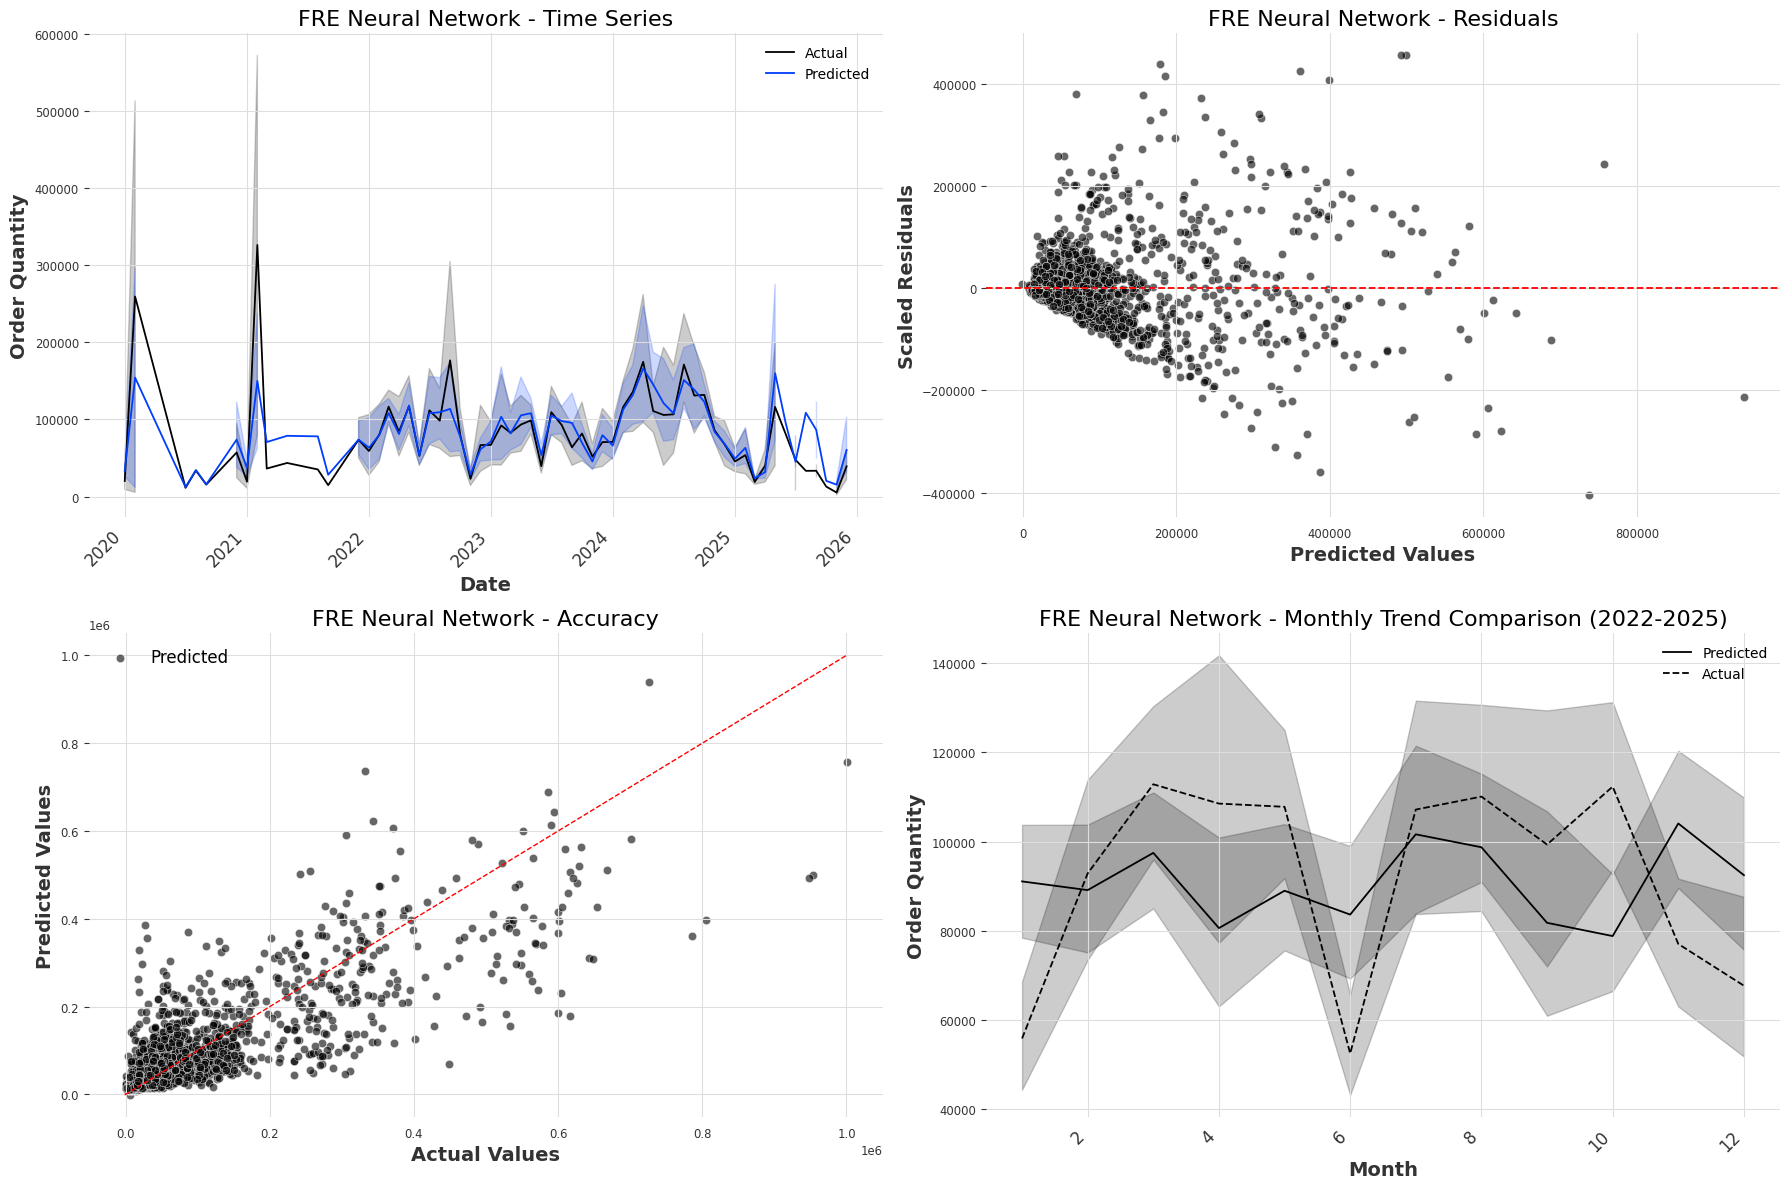

In [22]:
# Create subplots (2 rows, 2 columns: one for line plot, one for residual plot)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12)) 
fig.subplots_adjust(hspace=0.5, wspace=0.4)

# Time Series Comparison
sns.lineplot(x=custom_code_df.loc[y_val.index, 'OrderDate'], y=y_val, label='Actual', ax=axes[0, 0])
sns.lineplot(x=custom_code_df.loc[y_val.index, 'OrderDate'], y=val_pred_stacked, label='Predicted', ax=axes[0, 0])
axes[0, 0].set_title(f'{custom_ref} Neural Network - Time Series', fontsize=16)
axes[0, 0].set_xlabel('Date', fontsize=14)  
axes[0, 0].set_ylabel('Order Quantity', fontsize=14)

# Residual Plot
residuals = y_val - val_pred_stacked
sns.scatterplot(x=val_pred_stacked, y=residuals, alpha=0.6, ax=axes[0, 1])
axes[0, 1].axhline(0, color='r', linestyle='--')
axes[0, 1].set_title(f'{custom_ref} Neural Network - Residuals', fontsize=16)  
axes[0, 1].set_xlabel('Predicted Values', fontsize=14)  
axes[0, 1].set_ylabel('Scaled Residuals', fontsize=14)

# Actual vs Predicted Scatter Plot
min_val = min(y_val.min(), val_pred_stacked.min())
max_val = max(y_val.max(), val_pred_stacked.max())
sns.scatterplot(x=y_val, y=val_pred_stacked, alpha=0.6, ax=axes[1, 0], label='Predicted')
axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)  # Reference line
axes[1, 0].set_title(f'{custom_ref} Neural Network - Accuracy', fontsize=16)
axes[1, 0].set_xlabel('Actual Values', fontsize=14)
axes[1, 0].set_ylabel('Predicted Values', fontsize=14)  
axes[1, 0].legend(fontsize=12)

# Monthly Trend Comparison
monthly_data = custom_code_df[['order_month']].loc[custom_code_df.index.intersection(X_val.index)].copy()
monthly_data['Actual'] = y_val
monthly_data['Predicted'] = val_pred_stacked

sns.lineplot(x='order_month', y='Predicted', data=monthly_data, label='Predicted', ax=axes[1, 1])
sns.lineplot(x='order_month', y='Actual', data=monthly_data, label='Actual', ax=axes[1, 1], color='black', linestyle='--')
axes[1, 1].set_title(f'{custom_ref} Neural Network - Monthly Trend Comparison (2022-2025)', fontsize=16)  
axes[1, 1].set_xlabel('Month', fontsize=14)
axes[1, 1].set_ylabel('Order Quantity', fontsize=14)

# Adjust x-tick labels after all plots are drawn
plt.setp(axes[0, 0].get_xticklabels(), rotation=45, ha='right', fontsize=12)
plt.setp(axes[1, 1].get_xticklabels(), rotation=45, ha='right', fontsize=12)

plt.tight_layout()
plt.show()


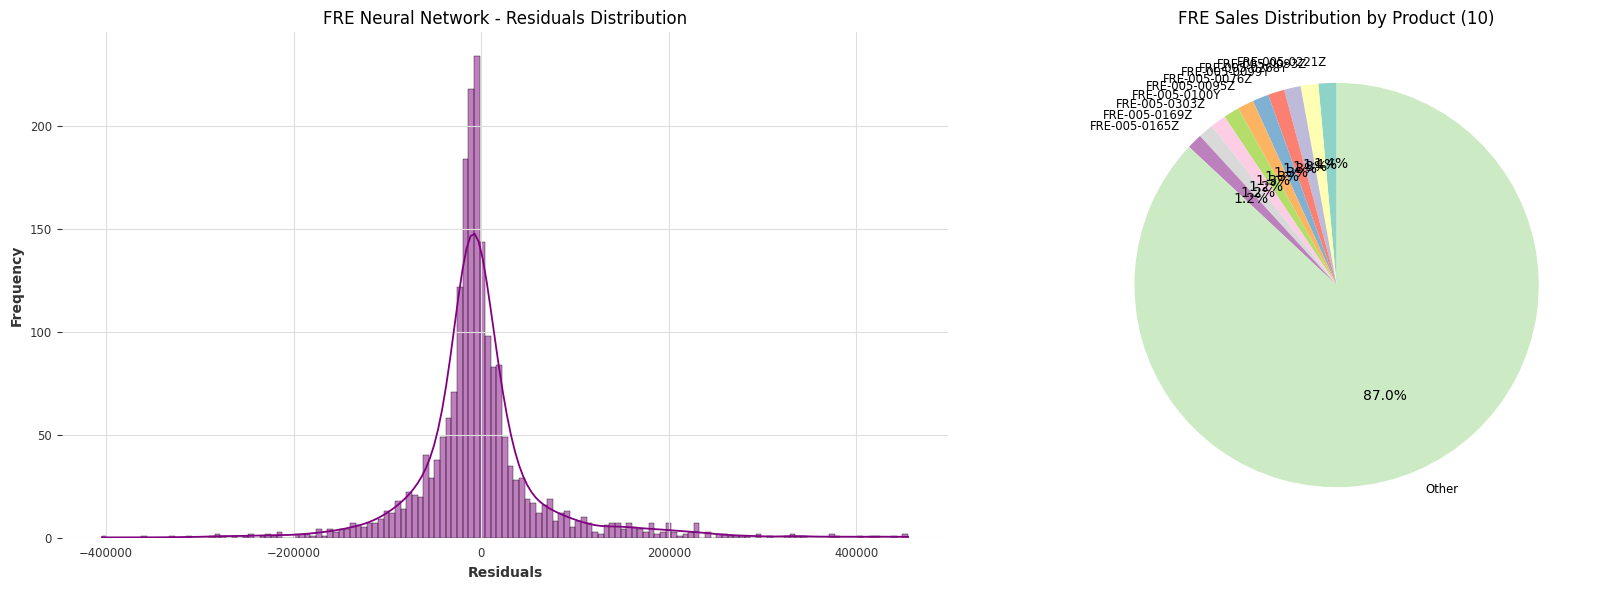

In [23]:
# Create subplots (1 row, 2 columns: one for line plot, one for residual plot)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# Histogram of Residuals
sns.histplot(residuals, kde=True, color='purple', ax=axes[0])
axes[0].set_title(f'{custom_ref} Neural Network - Residuals Distribution', fontsize=12)
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')

# Pie Chart of Product Order Quantity (Top {number} + Other)
product_sales = df.groupby('ProductNumber')['OrderQuantity'].sum()  # Group by product and sum order quantities

# Get the top 20 products by sales
top_products = product_sales.nlargest(10)

# Group the remaining products as 'Other'
other_sales = product_sales.drop(top_products.index).sum()
top_products['Other'] = other_sales

# Plot the pie chart
top_products.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set3', len(top_products)))
axes[1].set_title(f'{custom_ref} Sales Distribution by Product ({len(top_products) - 1})', fontsize=12)
axes[1].set_ylabel('')  # Hide the y-label for the pie chart

plt.tight_layout()
plt.show()

In [24]:
# Convert order year and month to datetime format
customer_total_df['OrderDate'] = pd.to_datetime(customer_total_df[['order_year', 'order_month']].astype(str).agg('-'.join, axis=1))

# Sort by OrderDate to maintain time order
customer_total_df = customer_total_df.sort_values(by='OrderDate')

In [25]:
# Ensure prediction and feature data are trimmed to match y_val_2024 length
total_X_val = total_X_val[:len(y_val_2024)]
val_pred_stacked = val_pred_stacked[:len(y_val_2024)]


NameError: name 'y_val_2024' is not defined

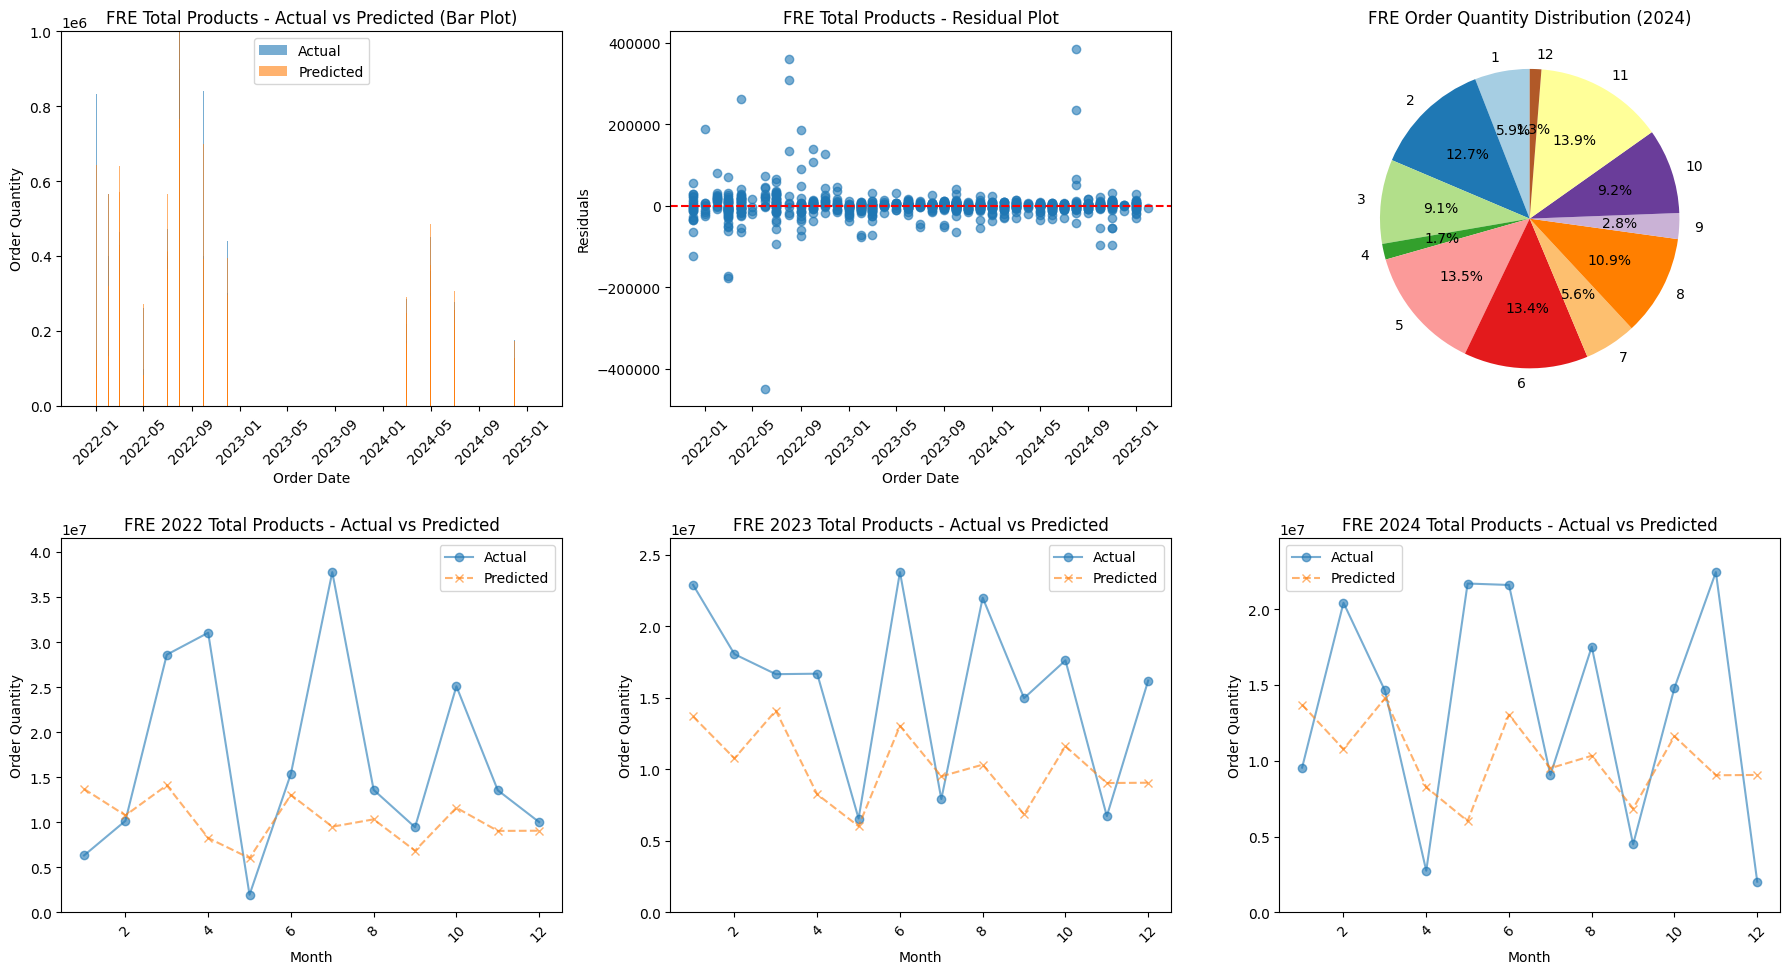

In [ ]:
# y_val_series = pd.Series(y_val, index=X_val.index)
# y_val_pred_series = pd.Series(val_pred_stacked, index=X_val.index)

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# Bar plot: Actual vs. Predicted
axes[0, 0].bar(
    customer_total_df.loc[total_X_val.index, 'OrderDate'], 
    total_y_val, 
    label='Actual', 
    alpha=0.6
)
axes[0, 0].bar(
    customer_total_df.loc[total_X_val.index, 'OrderDate'], 
    val_pred_stacked, 
    label='Predicted', 
    alpha=0.6
)
axes[0, 0].set_xlabel('Order Date')
axes[0, 0].set_ylabel('Order Quantity')
axes[0, 0].set_title(f'{custom_ref} Total Products - Actual vs Predicted (Bar Plot)')
axes[0, 0].set_ylim(0, 1_000_000)
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)

# Residual Plot
residuals = total_y_val - val_pred_stacked
axes[0, 1].scatter(
    customer_total_df.loc[total_X_val.index, 'OrderDate'], 
    residuals, 
    alpha=0.6
)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Order Date')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title(f'{custom_ref} Total Products - Residual Plot')
axes[0, 1].tick_params(axis='x', rotation=45)

# Pie Chart: Order Quantity Distribution (2024)
order_2024 = customer_total_df[customer_total_df['order_year'] == 2024] \
    .groupby('order_month')['OrderQuantity'].sum()
axes[0, 2].pie(
    order_2024,
    labels=order_2024.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Paired.colors
)
axes[0, 2].set_title(f'{custom_ref} Order Quantity Distribution (2024)')

# Line Plots: Yearly Trends
for i, year in enumerate([2022, 2023, 2024]):  
    yearly_df = customer_total_df[customer_total_df['order_year'] == year]
    if yearly_df.empty:
        continue

    # Aggregate OrderQuantity per month
    monthly_actual = yearly_df.groupby('order_month')['OrderQuantity'].sum()

    # Convert to Pandas Series with index from customer_total_df
    pred_series = pd.Series(val_pred_stacked, index=total_y_val.index)

    # Group predictions by month
    monthly_predicted = pred_series.groupby(customer_total_df.loc[total_y_val.index, 'order_month']).sum()

    # Sort for proper plotting
    monthly_actual = monthly_actual.sort_index()
    monthly_predicted = monthly_predicted.reindex(monthly_actual.index)  # Ensure same months

    # Plot
    axes[1, i].plot(
        monthly_actual.index,
        monthly_actual,
        label='Actual',
        alpha=0.6,
        marker='o',
        linestyle='-'
    )
    axes[1, i].plot(
        monthly_predicted.index,
        monthly_predicted,
        label='Predicted',
        alpha=0.6,
        marker='x',
        linestyle='--'
    )
    axes[1, i].set_xlabel('Month')
    axes[1, i].set_ylabel('Order Quantity')
    axes[1, i].set_title(f'{custom_ref} {year} Total Products - Actual vs Predicted')
    axes[1, i].set_ylim(0, max(monthly_actual.max(), monthly_predicted.max()) * 1.1)
    axes[1, i].legend()
    axes[1, i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
